[Step 7 - OpenAI embeddings (paid)]

> **MLCourse - Agentic AI - Embeddings**
> Stage in the capstone: EMBED - every chunk becomes a vector; query becomes one too.

## What you will learn

1. The key-guard pattern: paid demos must skip gracefully, never crash.
2. `OpenAIEmbeddings(model="text-embedding-3-small")` on the SAME three
   sentences as notebook 01, producing a mirror-image similarity matrix.
3. What 1536 dimensions mean versus MiniLM's 384 and nomic's 768.
4. Real cost arithmetic for embedding calls (spoiler: this demo is far
   below one tenth of a cent).
5. The SWAP PATTERN: identical downstream code, only the class changes.

**Scope note**: across the entire Agentic AI track, OpenAI appears in exactly
two notebooks - the providers notebook in module 01 and THIS file. Everything
else runs keyless. Here we honor that contract and keep the paid surface tiny,
guarded, and instructive.

In [1]:
# ---------------------------------------------------------------------------
# Setup cell (identical in every MLCourse notebook): imports, TRACK walker,
# DATA folder creation, .env loading, matplotlib inline magic - guarded so
# the file also runs as a plain script outside Jupyter.
# ---------------------------------------------------------------------------
from pathlib import Path


def find_track(start: Path, target: str = "03_agentic_ai") -> Path:
    """Climb parent folders until a directory named ``target`` shows up."""
    for candidate in [start, *start.parents]:
        probe = candidate / target
        if probe.is_dir():
            return probe
    raise FileNotFoundError(
        f"Could not find '{target}' above {start}. "
        "Open this notebook from inside the MLCourse repository."
    )


TRACK = find_track(Path.cwd())       # .../MLCourse/03_agentic_ai
DATA = TRACK / "data"                # one shared data folder for the track
DATA.mkdir(exist_ok=True)            # no-op when it already exists

from dotenv import load_dotenv       # noqa: E402  reads KEY=value files

load_dotenv()                        # .env beside the current directory
load_dotenv(TRACK / ".env")          # .env at the track root

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass                             # magic only exists inside IPython/Jupyter

import matplotlib.pyplot as plt      # noqa: E402

print("[setup] TRACK:", TRACK)
print("[setup] DATA :", DATA)

[setup] TRACK: D:\projects\python\MLCourse\03_agentic_ai
[setup] DATA : D:\projects\python\MLCourse\03_agentic_ai\data


## The guard pattern for paid cells

Rule of the course: every notebook executes top-to-bottom regardless of which
keys exist. So before touching a paid API we check ONCE whether the key is
present and branch on that boolean everywhere below. Missing key means the
notebook falls back to the free embedder - which doubles as proof that the
surrounding code truly does not care which embedder you pass it.

In [2]:
import os                            # getenv reads what load_dotenv populated

HAS_OPENAI = bool(os.getenv("OPENAI_API_KEY"))

if HAS_OPENAI:
    print("[guard] OPENAI_API_KEY found - paid demo will run.")
else:
    print("[guard] OPENAI_API_KEY missing.")
    print("[guard] add it to 03_agentic_ai/.env as: OPENAI_API_KEY=sk-...")
    print("[demo skipped] falling back to free MiniLM so every cell still runs.")
    print("[demo skipped] the pipeline below is IDENTICAL either way.")

[guard] OPENAI_API_KEY missing.
[guard] add it to 03_agentic_ai/.env as: OPENAI_API_KEY=sk-...
[demo skipped] falling back to free MiniLM so every cell still runs.
[demo skipped] the pipeline below is IDENTICAL either way.


## Same sentences, swappable embedder

Notice what does NOT change between branches: the sentence list, the cosine
math, the heatmap. Only the constructor line differs. That is the whole swap
pattern LangChain's `Embeddings` interface buys you - module 08 will rely on
exactly this when the same chunk list feeds Chroma or FAISS.

In [3]:
# Choose the embedder by key presence; everything downstream is shared code.
SENTENCES = [
    "Alice follows the white rabbit down the rabbit hole.",   # topic A
    "Alice chased the rabbit and fell into a deep hole.",     # topic A, paraphrased
    "Quantum processors factor large prime numbers fast.",    # topic B, unrelated
]

if HAS_OPENAI:
    # PAID branch - one of only two OpenAI appearances in the whole track.
    from langchain_openai import OpenAIEmbeddings
    embedder = OpenAIEmbeddings(model="text-embedding-3-small")
    TAG = "text-embedding-3-small (paid)"
else:
    # FREE fallback keeps the notebook runnable without any key.
    from langchain_huggingface import HuggingFaceEmbeddings
    embedder = HuggingFaceEmbeddings(
        model_name="sentence-transformers/all-MiniLM-L6-v2")
    TAG = "all-MiniLM-L6-v2 (free fallback)"

import numpy as np

vectors = np.array(embedder.embed_documents(SENTENCES))
print(TAG, "->", vectors.shape, "= (num_sentences, dims)")

if HAS_OPENAI:
    print("dimensionality:", vectors.shape[1],
          "(1536 for text-embedding-3-small)")
else:
    print("dimensionality:", vectors.shape[1],
          "(384 for MiniLM - set OPENAI_API_KEY to see 1536)")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

all-MiniLM-L6-v2 (free fallback) -> (3, 384) = (num_sentences, dims)
dimensionality: 384 (384 for MiniLM - set OPENAI_API_KEY to see 1536)


## The similarity matrix, mirroring notebook 01

Identical helper, identical heatmap layout - so you can compare the two
notebooks side by side and see whether money changes the geometry.

                rabbit hole  chased rabbit  quantum primes
rabbit hole           1.000          0.757          -0.017
chased rabbit         0.757          1.000           0.012
quantum primes       -0.017          0.012           1.000


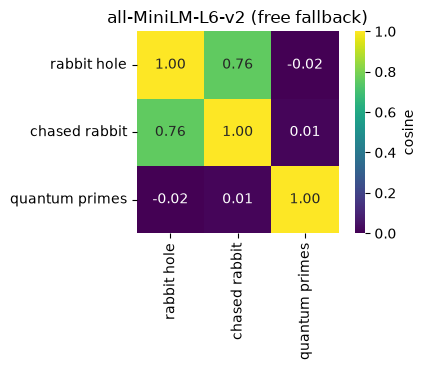


related pair ~0.757 | unrelated pair ~-0.017
Same qualitative picture as the free model - quality differences
show up on hard/multilingual cases, not on toy examples.


In [4]:
import pandas as pd


def cosine_similarity_matrix(vecs: np.ndarray) -> np.ndarray:
    """Pairwise cosine similarity.

    cos(a, b) = dot(a, b) / (norm(a) * norm(b))
              = angle only, immune to vector lengths.
    """
    norms = np.linalg.norm(vecs, axis=1, keepdims=True)
    unit = vecs / norms                                  # normalize rows once
    return unit @ unit.T                                 # dot == cosine now


sim = cosine_similarity_matrix(vectors)

LABELS = ["rabbit hole", "chased rabbit", "quantum primes"]
sim_df = pd.DataFrame(np.round(sim, 3), index=LABELS, columns=LABELS)
print(sim_df)

fig, ax = plt.subplots(figsize=(4.8, 3.8))
try:
    import seaborn as sns
    sns.heatmap(sim_df, annot=True, fmt=".2f", cmap="viridis",
                vmin=0.0, vmax=1.0, square=True, ax=ax,
                cbar_kws={"label": "cosine"})
except ImportError:                                      # seaborn optional
    im = ax.imshow(sim, cmap="viridis", vmin=0.0, vmax=1.0)
    ax.set_xticks(range(3), LABELS, rotation=45, ha="right")
    ax.set_yticks(range(3), LABELS)
    fig.colorbar(im, ax=ax, label="cosine")
ax.set_title(TAG)
plt.tight_layout()
plt.show()

related, unrelated = sim[0, 1], sim[0, 2]
print("\nrelated pair ~%.3f | unrelated pair ~%.3f" % (related, unrelated))
print("Same qualitative picture as the free model - quality differences")
print("show up on hard/multilingual cases, not on toy examples.")

## Cost arithmetic, made concrete

List price for text-embedding-3-small is about $0.02 per 1M tokens. Our three
short sentences are roughly 30 tokens total. Walk the numbers yourself - the
point is that DEMO-scale usage rounds to zero, while corpus-scale usage
(millions of chunks, re-embedded on every experiment) is where bills live.

In [5]:
PRICE_PER_1M_TOKENS_USD = 0.02                  # text-embedding-3-small pricing

approx_tokens = sum(len(s.split()) for s in SENTENCES)   # rough: word ~= token
demo_cost_usd = approx_tokens / 1_000_000 * PRICE_PER_1M_TOKENS_USD

alice_words = 26_000                            # alice.txt is about this long
alice_cost_usd = alice_words / 1_000_000 * PRICE_PER_1M_TOKENS_USD

print("tokens sent this demo      :", approx_tokens)
print("price per 1M tokens        : $%.2f" % PRICE_PER_1M_TOKENS_USD)
print("THIS demo costs            : $%.7f  (far under $0.001)" % demo_cost_usd)
print("embedding all of alice.txt : $%.6f per full pass" % alice_cost_usd)
print("Lesson: price per call is trivial; price per HABIT is the real number.")

tokens sent this demo      : 26
price per 1M tokens        : $0.02
THIS demo costs            : $0.0000005  (far under $0.001)
embedding all of alice.txt : $0.000520 per full pass
Lesson: price per call is trivial; price per HABIT is the real number.


## Swap-pattern proof

One function, two embedders, zero branching inside the function body. If you
have both options available, run this cell twice - once with the key, once
without - and watch the SAME code produce both matrices.

In [6]:
def similarity_report(embedder_obj, texts):
    """Works for ANY LangChain Embeddings object - that IS the swap pattern."""
    vecs = np.array(embedder_obj.embed_documents(texts))
    return cosine_similarity_matrix(vecs)


if HAS_OPENAI:
    from langchain_openai import OpenAIEmbeddings
    paid_matrix = similarity_report(
        OpenAIEmbeddings(model="text-embedding-3-small"), SENTENCES)
    print("[paid]   A-vs-B cosine: %.3f | A-vs-C cosine: %.3f"
          % (paid_matrix[0, 1], paid_matrix[0, 2]))

from langchain_huggingface import HuggingFaceEmbeddings
free_matrix = similarity_report(
    HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2"),
    SENTENCES)
print("[free]   A-vs-B cosine: %.3f | A-vs-C cosine: %.3f"
      % (free_matrix[0, 1], free_matrix[0, 2]))
print("\nOnly the CONSTRUCTOR line changed. Keep this trick for A/B testing")
print("embedders against your own retrieval benchmarks later in the track.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[free]   A-vs-B cosine: 0.757 | A-vs-C cosine: -0.017

Only the CONSTRUCTOR line changed. Keep this trick for A/B testing
embedders against your own retrieval benchmarks later in the track.


## Takeaway

- Guard paid APIs once (`HAS_OPENAI`) and let every cell degrade gracefully.
- text-embedding-3-small returns 1536-dim vectors; geometry on easy cases
  mirrors the free models - you pay for robustness on hard ones.
- Demo cost is microscopic ($0.000000x); design for cost at CORPUS scale.
- The swap pattern means your retrieval stack is embedder-agnostic forever.

## Summary

We ran the exact notebook-01 pipeline through OpenAI's paid embedder behind a
clean key guard, mirrored the cosine matrix and heatmap, printed the 1536
dimensionality, did honest cost arithmetic, and proved via one shared
function that switching embedders is a one-line change. This was the second
and LAST OpenAI appearance in the track - modules 08+ stay fully keyless.